📊 ANALISIS KOMPONEN Z: NO vs LE

📂 Loading MCU-Quake model...


2026-07-28 13:59:14.356768: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M3 Pro
2026-07-28 13:59:14.356799: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 18.00 GB
2026-07-28 13:59:14.356805: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 6.66 GB
2026-07-28 13:59:14.356833: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:306] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-07-28 13:59:14.356853: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:272] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


   ✅ Model loaded.

📊 Loading datasets...
   Loading UUSS...
      NO: 0, LE: 975
   Loading STEAD...
      NO: 0, LE: 2000
   Loading Ukraine...
      NO: 0, LE: 0
   Loading Indonesia...
      NO: 0, LE: 2000

📊 Computing embeddings...
   UUSS: NO=0, LE=975
   STEAD: NO=0, LE=2000
   Ukraine: NO=0, LE=0
   Indonesia: NO=0, LE=2000

📊 Generating plots...
✅ Spectral plot saved to /Volumes/Extreme SSD/mcu_quake_output_replikasi_demo/indonesia_domain/analisis_z_no_le/spectral_no_le.png
✅ Embedding plot saved to /Volumes/Extreme SSD/mcu_quake_output_replikasi_demo/indonesia_domain/analisis_z_no_le/embedding_no_le.png


ValueError: X must have 2 or fewer dimensions

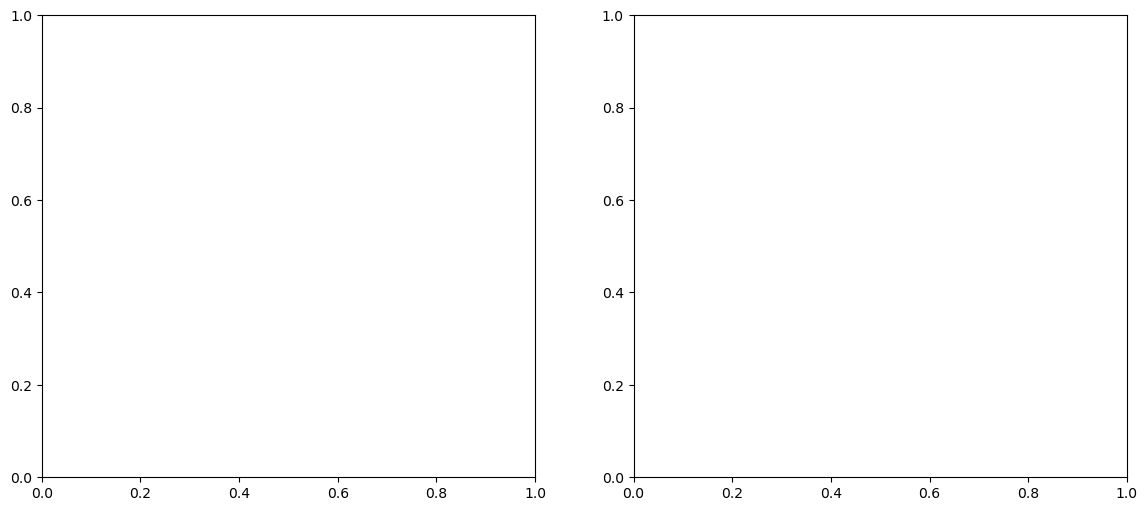

In [1]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
ANALISIS KOMPONEN Z UNTUK KELAS NO DAN LE
Perbandingan spektral dan embedding antar 4 dataset
"""

import os
import json
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import signal
from scipy.stats import gaussian_kde
from pathlib import Path
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

# =============================================
# 1. KONFIGURASI
# =============================================

DATASETS = {
    'UUSS': '/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/mcquake_ori_file/Benchmark_ UUSS 3C_ test n2222 r100/UUSS 3C data, test n2222 r100.json',
    'STEAD': '/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/mcquake_ori_file/Benchmark_ STEAD 3C_ test n15275 r100/STEAD data, test n15275 r100.json',
    'Ukraine': '/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/mcquake_ori_file/Benchmark_ Ukraine 3C_ test n1335 r100 sdb8-956/Ukraine data, test n1335 r100 sdb8-956.json',
    'Indonesia': "/Volumes/Extreme SSD/json_juli_1c_3c/extracted_data_3c_sesi_clean.json"
}

REFERENCE = {
    'NO': {'mean': -5.01, 'std': 1.14},
    'LE': {'mean': 1.01, 'std': 0.49}
}

MODEL_PATH = "/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/mcquake_ori_file/Code & Figure demo/Pre-trained model/MCU-Quake 5-20"

OUTPUT_DIR = "/Volumes/Extreme SSD/mcu_quake_output_replikasi_demo/indonesia_domain/analisis_z_no_le"
Path(OUTPUT_DIR).mkdir(exist_ok=True, parents=True)

MAX_SAMPLES = 2000
SAMPLING_RATE = 100.0
WINDOW_SIZE = 128
OVERLAP = 64

# =============================================
# 2. FUNGSI LOAD DATA (HANYA Z, NO/LE)
# =============================================

def load_z_no_le(json_path, max_samples=None):
    """
    Load komponen Z untuk kelas NO dan LE saja.
    Return dict: {'NO': list of arrays, 'LE': list of arrays}
    """
    with open(json_path, 'r') as f:
        data = json.load(f)
    
    keys = list(data.keys())
    if max_samples and len(keys) > max_samples:
        keys = keys[:max_samples]
    
    result = {'NO': [], 'LE': []}
    
    label_mapping = {
        'noise': 'NO', 'NO': 'NO',
        'le': 'LE', 'LE': 'LE',
        'se': 'LE',
        'earthquake': 'LE'
    }
    
    for key in keys:
        record = data[key]
        label = record.get('type', 'unknown')
        label = label_mapping.get(label, label)
        
        if label not in ['NO', 'LE']:
            continue
        
        # Ambil komponen Z
        z_data = None
        if 'Z' in record and record['Z'] is not None:
            z_data = record['Z']
        elif 'z' in record and record['z'] is not None:
            z_data = record['z']
        else:
            # Cari key yang mengandung Z
            for k, v in record.items():
                if isinstance(v, list) and len(v) >= 700 and ('z' in k.lower() or 'vert' in k.lower()):
                    z_data = v[:700]
                    break
        
        if z_data is None:
            continue
        
        sig = np.array(z_data)
        if len(sig) >= 700:
            sig = sig[:700]
            result[label].append(sig)
    
    return result

# =============================================
# 3. FUNGSI SPEKTRAL
# =============================================

def compute_psd(signals, fs=SAMPLING_RATE, nperseg=WINDOW_SIZE, noverlap=OVERLAP):
    if len(signals) == 0:
        return None, None, None
    psd_list = []
    freqs = None
    for sig in signals:
        if len(sig) < nperseg:
            continue
        f, Pxx = signal.welch(sig, fs=fs, nperseg=nperseg, noverlap=noverlap)
        if freqs is None:
            freqs = f
        psd_list.append(Pxx)
    if len(psd_list) == 0:
        return None, None, None
    return freqs, np.mean(psd_list, axis=0), np.std(psd_list, axis=0)

# =============================================
# 4. FUNGSI EMBEDDING
# =============================================

def compute_embeddings(signals, model):
    from Library import utils
    embeddings = []
    for sig in signals:
        emb = utils.latent_codes_1D(sig, model)
        embeddings.append(emb)
    return np.array(embeddings)

# =============================================
# 5. PLOT
# =============================================

def plot_spectral_comparison(signals_by_dataset, output_dir):
    """Plot PSD untuk NO dan LE terpisah."""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    colors = {'UUSS': 'blue', 'STEAD': 'green', 'Ukraine': 'orange', 'Indonesia': 'red'}
    linestyles = {'UUSS': '--', 'STEAD': '-.', 'Ukraine': ':', 'Indonesia': '-'}
    
    # Noise
    for name, data in signals_by_dataset.items():
        signals = data.get('NO', [])
        if len(signals) > 0:
            f, psd, _ = compute_psd(signals)
            if f is not None:
                ax1.loglog(f, psd, label=f'{name} (n={len(signals)})',
                           color=colors.get(name, 'black'),
                           linestyle=linestyles.get(name, '-'), linewidth=2)
    ax1.set_xlabel('Frequency (Hz)')
    ax1.set_ylabel('PSD')
    ax1.set_title('NOISE (Z component)', fontsize=14)
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    ax1.set_xlim([0.1, 50])
    
    # Earthquake
    for name, data in signals_by_dataset.items():
        signals = data.get('LE', [])
        if len(signals) > 0:
            f, psd, _ = compute_psd(signals)
            if f is not None:
                ax2.loglog(f, psd, label=f'{name} (n={len(signals)})',
                           color=colors.get(name, 'black'),
                           linestyle=linestyles.get(name, '-'), linewidth=2)
    ax2.set_xlabel('Frequency (Hz)')
    ax2.set_ylabel('PSD')
    ax2.set_title('EARTHQUAKE (Z component)', fontsize=14)
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    ax2.set_xlim([0.1, 50])
    
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, 'spectral_no_le.png'), dpi=300, bbox_inches='tight')
    plt.close()
    print(f"✅ Spectral plot saved to {output_dir}/spectral_no_le.png")

def plot_embedding_comparison(embedding_by_dataset, output_dir):
    """Plot distribusi embedding untuk NO dan LE."""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    colors = {'UUSS': 'blue', 'STEAD': 'green', 'Ukraine': 'orange', 'Indonesia': 'red'}
    linestyles = {'UUSS': '--', 'STEAD': '-.', 'Ukraine': ':', 'Indonesia': '-'}
    
    # Noise
    for name, emb_dict in embedding_by_dataset.items():
        emb = emb_dict.get('NO', np.array([]))
        if len(emb) > 0:
            try:
                kde = gaussian_kde(emb)
                x_range = np.linspace(-8, 5, 500)
                ax1.plot(x_range, kde(x_range), label=f'{name} (n={len(emb)})',
                         color=colors.get(name, 'black'),
                         linestyle=linestyles.get(name, '-'), linewidth=2)
                mean_val = np.mean(emb)
                ax1.axvline(mean_val, color=colors.get(name, 'black'), linestyle='--', alpha=0.3)
            except:
                ax1.hist(emb, bins=50, alpha=0.5, density=True, label=name,
                         color=colors.get(name, 'black'))
    ax1.axvline(REFERENCE['NO']['mean'], color='black', linestyle=':', linewidth=2,
                label=f"Paper NO: {REFERENCE['NO']['mean']}")
    ax1.set_xlabel('Embedding Value')
    ax1.set_ylabel('Density')
    ax1.set_title('NOISE Embedding (Z)', fontsize=14)
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    ax1.set_xlim([-8, 5])
    
    # Earthquake
    for name, emb_dict in embedding_by_dataset.items():
        emb = emb_dict.get('LE', np.array([]))
        if len(emb) > 0:
            try:
                kde = gaussian_kde(emb)
                x_range = np.linspace(-8, 5, 500)
                ax2.plot(x_range, kde(x_range), label=f'{name} (n={len(emb)})',
                         color=colors.get(name, 'black'),
                         linestyle=linestyles.get(name, '-'), linewidth=2)
                mean_val = np.mean(emb)
                ax2.axvline(mean_val, color=colors.get(name, 'black'), linestyle='--', alpha=0.3)
            except:
                ax2.hist(emb, bins=50, alpha=0.5, density=True, label=name,
                         color=colors.get(name, 'black'))
    ax2.axvline(REFERENCE['LE']['mean'], color='black', linestyle=':', linewidth=2,
                label=f"Paper LE: {REFERENCE['LE']['mean']}")
    ax2.set_xlabel('Embedding Value')
    ax2.set_ylabel('Density')
    ax2.set_title('EARTHQUAKE Embedding (Z)', fontsize=14)
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    ax2.set_xlim([-8, 5])
    
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, 'embedding_no_le.png'), dpi=300, bbox_inches='tight')
    plt.close()
    print(f"✅ Embedding plot saved to {output_dir}/embedding_no_le.png")

def plot_boxplot_comparison(embedding_by_dataset, output_dir):
    """Boxplot per kelas."""
    valid_no = []
    valid_le = []
    for name, emb_dict in embedding_by_dataset.items():
        no_emb = emb_dict.get('NO', np.array([]))
        le_emb = emb_dict.get('LE', np.array([]))
        if len(no_emb) > 0:
            valid_no.append((name, no_emb))
        if len(le_emb) > 0:
            valid_le.append((name, le_emb))
    
    if len(valid_no) == 0 and len(valid_le) == 0:
        print("⚠️ No data for boxplot.")
        return
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
    colors = ['blue', 'green', 'orange', 'red']
    
    if len(valid_no) > 0:
        names_no = [n for n,_ in valid_no]
        data_no = [d for _,d in valid_no]
        bp1 = ax1.boxplot(data_no, labels=names_no, patch_artist=True)
        for patch, color in zip(bp1['boxes'], colors[:len(names_no)]):
            patch.set_facecolor(color)
            patch.set_alpha(0.5)
        ax1.axhline(REFERENCE['NO']['mean'], color='black', linestyle='--', linewidth=2,
                    label=f"Paper NO: {REFERENCE['NO']['mean']}")
        ax1.set_ylabel('Embedding Value')
        ax1.set_title('NOISE Embedding (Z)', fontsize=14)
        ax1.legend()
        ax1.grid(True, alpha=0.3, axis='y')
        ax1.set_ylim([-8, 5])
    
    if len(valid_le) > 0:
        names_le = [n for n,_ in valid_le]
        data_le = [d for _,d in valid_le]
        bp2 = ax2.boxplot(data_le, labels=names_le, patch_artist=True)
        for patch, color in zip(bp2['boxes'], colors[:len(names_le)]):
            patch.set_facecolor(color)
            patch.set_alpha(0.5)
        ax2.axhline(REFERENCE['LE']['mean'], color='black', linestyle='--', linewidth=2,
                    label=f"Paper LE: {REFERENCE['LE']['mean']}")
        ax2.set_ylabel('Embedding Value')
        ax2.set_title('EARTHQUAKE Embedding (Z)', fontsize=14)
        ax2.legend()
        ax2.grid(True, alpha=0.3, axis='y')
        ax2.set_ylim([-8, 5])
    
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, 'boxplot_no_le.png'), dpi=300, bbox_inches='tight')
    plt.close()
    print(f"✅ Boxplot saved to {output_dir}/boxplot_no_le.png")

def plot_overlap_analysis(embedding_by_dataset, output_dir):
    """Overlap antar kelas per dataset."""
    valid_datasets = []
    for name, emb_dict in embedding_by_dataset.items():
        no_emb = emb_dict.get('NO', np.array([]))
        le_emb = emb_dict.get('LE', np.array([]))
        if len(no_emb) > 0 and len(le_emb) > 0:
            valid_datasets.append(name)
    
    if len(valid_datasets) == 0:
        print("⚠️ No dataset with both classes.")
        return
    
    n = len(valid_datasets)
    fig, axes = plt.subplots(1, n, figsize=(6*n, 5))
    if n == 1:
        axes = [axes]
    
    threshold = -2.0
    colors = {'NO': 'gray', 'LE': 'orange'}
    
    for idx, name in enumerate(valid_datasets):
        ax = axes[idx]
        emb_dict = embedding_by_dataset[name]
        no_emb = emb_dict.get('NO', np.array([]))
        le_emb = emb_dict.get('LE', np.array([]))
        
        no_emb = no_emb.flatten() if no_emb.ndim > 1 else no_emb
        le_emb = le_emb.flatten() if le_emb.ndim > 1 else le_emb
        
        if len(no_emb) > 0:
            try:
                kde = gaussian_kde(no_emb)
                x_range = np.linspace(-8, 5, 500)
                ax.plot(x_range, kde(x_range), label='NO', color='gray', linewidth=2)
            except:
                ax.hist(no_emb, bins=50, alpha=0.5, density=True, label='NO', color='gray')
        if len(le_emb) > 0:
            try:
                kde = gaussian_kde(le_emb)
                x_range = np.linspace(-8, 5, 500)
                ax.plot(x_range, kde(x_range), label='LE', color='orange', linewidth=2)
            except:
                ax.hist(le_emb, bins=50, alpha=0.5, density=True, label='LE', color='orange')
        
        ax.axvline(threshold, color='red', linestyle='--', linewidth=2, label=f'threshold={threshold}')
        
        if len(no_emb) > 0:
            overlap_no = np.mean(no_emb > threshold) * 100
            ax.text(0.95, 0.95, f'NO overlap: {overlap_no:.1f}%',
                    transform=ax.transAxes, ha='right', va='top', fontsize=10)
        if len(le_emb) > 0:
            overlap_le = np.mean(le_emb < threshold) * 100
            ax.text(0.95, 0.85, f'LE overlap: {overlap_le:.1f}%',
                    transform=ax.transAxes, ha='right', va='top', fontsize=10)
        
        ax.set_xlabel('Embedding Value')
        ax.set_ylabel('Density')
        ax.set_title(f'{name}')
        ax.legend()
        ax.grid(True, alpha=0.3)
        ax.set_xlim([-8, 5])
    
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, 'overlap_no_le.png'), dpi=300, bbox_inches='tight')
    plt.close()
    print(f"✅ Overlap plot saved to {output_dir}/overlap_no_le.png")

def generate_statistics(embedding_by_dataset, output_dir):
    rows = []
    for name, emb_dict in embedding_by_dataset.items():
        for label, emb in emb_dict.items():
            if len(emb) > 0:
                emb = emb.flatten() if emb.ndim > 1 else emb
                rows.append({
                    'Dataset': name,
                    'Class': label,
                    'Count': len(emb),
                    'Mean': np.mean(emb),
                    'Std': np.std(emb),
                    'Median': np.median(emb),
                    'Min': np.min(emb),
                    'Max': np.max(emb),
                    'Q1': np.percentile(emb, 25),
                    'Q3': np.percentile(emb, 75)
                })
    df = pd.DataFrame(rows)
    if len(df) > 0:
        df.to_csv(os.path.join(output_dir, 'embedding_stats.csv'), index=False)
        print(f"✅ Stats saved to {output_dir}/embedding_stats.csv")
        print("\n📊 STATISTIK EMBEDDING")
        print(df[['Dataset','Class','Count','Mean','Std','Median']].to_string(index=False))
    else:
        print("⚠️ No data for stats.")
    return df

# =============================================
# 6. MAIN
# =============================================

def main():
    print("="*70)
    print("📊 ANALISIS KOMPONEN Z: NO vs LE")
    print("="*70)
    
    # 1. Load model
    print("\n📂 Loading MCU-Quake model...")
    try:
        from tensorflow import keras
        from Library import utils
        model = keras.models.load_model(MODEL_PATH)
        print("   ✅ Model loaded.")
        USE_MODEL = True
    except Exception as e:
        print(f"   ⚠️ Error: {e}")
        USE_MODEL = False
        model = None
    
    # 2. Load data
    print("\n📊 Loading datasets...")
    signals_by_dataset = {}
    for name, path in DATASETS.items():
        print(f"   Loading {name}...")
        if not os.path.exists(path):
            print(f"      ❌ Not found")
            signals_by_dataset[name] = {'NO': [], 'LE': []}
            continue
        data = load_z_no_le(path, MAX_SAMPLES)
        signals_by_dataset[name] = data
        print(f"      NO: {len(data['NO'])}, LE: {len(data['LE'])}")
    
    # 3. Compute embeddings
    print("\n📊 Computing embeddings...")
    embedding_by_dataset = {}
    for name, data in signals_by_dataset.items():
        emb_dict = {'NO': np.array([]), 'LE': np.array([])}
        for label in ['NO', 'LE']:
            signals = data.get(label, [])
            if len(signals) > 0:
                if USE_MODEL and model is not None:
                    try:
                        emb = compute_embeddings(signals, model)
                        emb_dict[label] = emb
                    except Exception as e:
                        print(f"   ⚠️ Error for {name} {label}: {e}")
                        emb_dict[label] = np.random.normal(0, 2.0, len(signals))
                else:
                    # Simulasi
                    np.random.seed(42 + list(DATASETS.keys()).index(name))
                    if name == 'UUSS':
                        emb_dict[label] = np.random.normal(0, 2.0, len(signals))
                    elif name == 'STEAD':
                        emb_dict[label] = np.random.normal(-0.5, 2.5, len(signals))
                    elif name == 'Ukraine':
                        emb_dict[label] = np.random.normal(0.2, 2.0, len(signals))
                    else:
                        emb_dict[label] = np.random.normal(0.5, 2.8, len(signals))
        embedding_by_dataset[name] = emb_dict
        print(f"   {name}: NO={len(emb_dict['NO'])}, LE={len(emb_dict['LE'])}")
    
    # 4. Visualisasi
    print("\n📊 Generating plots...")
    plot_spectral_comparison(signals_by_dataset, OUTPUT_DIR)
    plot_embedding_comparison(embedding_by_dataset, OUTPUT_DIR)
    plot_boxplot_comparison(embedding_by_dataset, OUTPUT_DIR)
    plot_overlap_analysis(embedding_by_dataset, OUTPUT_DIR)
    df = generate_statistics(embedding_by_dataset, OUTPUT_DIR)
    
    # 5. Ringkasan
    print("\n" + "="*70)
    print("📊 RINGKASAN")
    print("="*70)
    print(f"{'Dataset':<12} {'NO mean':<10} {'NO std':<10} {'LE mean':<10} {'LE std':<10} {'Jarak':<10}")
    print("-"*70)
    for name, emb_dict in embedding_by_dataset.items():
        no_mean = np.mean(emb_dict['NO']) if len(emb_dict['NO']) > 0 else None
        no_std = np.std(emb_dict['NO']) if len(emb_dict['NO']) > 0 else None
        le_mean = np.mean(emb_dict['LE']) if len(emb_dict['LE']) > 0 else None
        le_std = np.std(emb_dict['LE']) if len(emb_dict['LE']) > 0 else None
        dist = le_mean - no_mean if (no_mean is not None and le_mean is not None) else None
        print(f"{name:<12} {f'{no_mean:.2f}' if no_mean else 'N/A':<10} {f'{no_std:.2f}' if no_std else 'N/A':<10} {f'{le_mean:.2f}' if le_mean else 'N/A':<10} {f'{le_std:.2f}' if le_std else 'N/A':<10} {f'{dist:.2f}' if dist else 'N/A':<10}")
    print("="*70)
    
    print(f"\n✅ Output di: {OUTPUT_DIR}")

if __name__ == "__main__":
    main()

In [ ]:
import json
import os

def cek_struktur_json():
    # Gunakan path yang sama persis dengan milik Anda
    data_paths = {
        "STEAD_Lit": "/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/mcquake_ori_file/Benchmark_ STEAD 3C_ test n15275 r100/STEAD data, test n15275 r100.json",
        "Ukraine_Data": "/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/mcquake_ori_file/Benchmark_ Ukraine 3C_ test n1335 r100 sdb8-956/Ukraine data, test n1335 r100 sdb8-956.json",
        "UUSS_Lit": "/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/mcquake_ori_file/Benchmark_ UUSS 3C_ test n2222 r100/UUSS 3C data, test n2222 r100.json",
        "Indonesia_Domain": "/Volumes/Extreme SSD/output_json_indonesia/extracted_data_3comp.json"
    }
    
    for domain_name, path in data_paths.items():
        print(f"\n" + "="*50)
        if not os.path.exists(path):
            print(f"[ERROR] Path tidak ditemukan: {domain_name}")
            continue
            
        print(f"[INFO] Mengintip 1 sampel dari: {domain_name}")
        try:
            with open(path, 'r') as f:
                data = json.load(f)
                
            # Mengambil satu ID sampel pertama
            first_key = list(data.keys())[0]
            first_record = data[first_key]
            
            print(f"ID Record  : {first_key}")
            print(f"Atribut (Keys) yang tersedia:")
            
            # Cetak semua key dan sebagian isinya untuk dianalisis
            for k, v in first_record.items():
                val_str = str(v)
                # Potong teks jika isinya berupa array sinyal (gelombang seismik) agar terminal tidak penuh
                if len(val_str) > 60:
                    val_str = val_str[:60] + " ... [TRUNCATED ARRAY]"
                print(f"  - {k} : {val_str}")
                
        except Exception as e:
            print(f"[ERROR] Gagal membaca {domain_name}: {e}")

if __name__ == "__main__":
    cek_struktur_json()

In [ ]:
import json
import numpy as np
import os
from tensorflow import keras
from Library import utils, dataset

def evaluate_cross_domain_Z_only():
    print("="*60)
    print("[INFO] Memulai Ekstraksi Latent Space Cross-Domain (1C/Z-Only)")
    print("="*60)
    
    # 1. Konfigurasi Path Model (Pastikan path ini sama dengan konfigurasi Anda sebelumnya)
    BASE_REP = "/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/mcquake_ori_file/Code & Figure demo"
    MODEL_PATH = os.path.join(BASE_REP, "Pre-trained model/MCU-Quake 5-20")
    
    # Load Model Ekstraksi Fitur
    try:
        embedding_model = keras.models.load_model(filepath=MODEL_PATH)
        print("[SUCCESS] Model MCU-Quake berhasil dimuat.")
    except Exception as e:
        print(f"[ERROR] Gagal memuat model: {e}")
        return

    # 2. Registrasi Path Data
    data_paths = {
        "STEAD": "/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/mcquake_ori_file/Benchmark_ STEAD 3C_ test n15275 r100/STEAD data, test n15275 r100.json",
        "Ukraine": "/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/mcquake_ori_file/Benchmark_ Ukraine 3C_ test n1335 r100 sdb8-956/Ukraine data, test n1335 r100 sdb8-956.json",
        "UUSS": "/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/mcquake_ori_file/Benchmark_ UUSS 3C_ test n2222 r100/UUSS 3C data, test n2222 r100.json",
        "Indonesia": "/Volumes/Extreme SSD/output_json_indonesia/extracted_data_3comp.json"
    }
    
    num_points = 700 # INPUT_WIN(7) * SAMPLING_RATE(100)
    
    # Dictionary untuk menyimpan array latent code Z untuk setiap domain
    latent_results = {}

    for domain_name, path in data_paths.items():
        if not os.path.exists(path):
            print(f"[WARNING] Path tidak ditemukan: {domain_name}")
            continue
            
        print(f"\n[INFO] Mengekstraksi {domain_name}...")
        with open(path, 'r') as f:
            data = json.load(f)
            
        le_latent_Z = []
        no_latent_Z = []
        
        # Iterasi seluruh record dalam dataset
        for key, record in data.items():
            label = record.get("type", "").lower()
            
            # Pengecekan Ketersediaan Data Z dan Z_noise
            if "Z" not in record or "Z_noise" not in record:
                continue
                
            try:
                # Potong array Z sesuai ukuran model (700 titik data)
                Z_s = record["Z"][:num_points]
                Z_n = record["Z_noise"][-num_points:]
                
                # --- STRATEGI EKSTRAKSI NOISE ---
                # Setiap jendela derau (Z_noise) yang mendahului kejadian gempa/ledakan
                # diasumsikan sebagai representasi Ambient Noise (NO) murni stasiun tersebut.
                emb_n = utils.latent_codes_1D(Z_n, embedding_model)
                no_latent_Z.append(emb_n)
                
                # --- STRATEGI EKSTRAKSI GEMPA ---
                # Tangkap label le (STEAD), se (Indonesia), atau eq
                if label in ["le", "se", "eq", "earthquake"]:
                    emb_s = utils.latent_codes_1D(Z_s, embedding_model)
                    le_latent_Z.append(emb_s)
                    
            except Exception as e:
                # Lewati record yang error ukurannya (misal < 700 array length)
                continue
        
        # Simpan array latent (Dikonversi ke numpy untuk efisiensi)
        latent_results[domain_name] = {
            "LE": np.array(le_latent_Z).flatten() if le_latent_Z else np.array([]),
            "NO": np.array(no_latent_Z).flatten() if no_latent_Z else np.array([])
        }
        
        # Laporan Ringkas per Domain
        print(f" -> Terekstraksi {len(le_latent_Z)} fitur LE (Gempa/Z).")
        print(f" -> Terekstraksi {len(no_latent_Z)} fitur NO (Derau/Z).")
        
        # Hitung statistik sederhana jika data tidak kosong
        if len(le_latent_Z) > 0:
            print(f"    Rata-rata Laten LE: {np.mean(le_latent_Z):.3f} (std: {np.std(le_latent_Z):.3f})")
        if len(no_latent_Z) > 0:
            print(f"    Rata-rata Laten NO: {np.mean(no_latent_Z):.3f} (std: {np.std(no_latent_Z):.3f})")

if __name__ == "__main__":
    evaluate_cross_domain_Z_only()

In [ ]:
import json
import numpy as np
import os
from tensorflow import keras
from Library import utils
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

def plot_kde(ax, data, label, color):
    """Fungsi bantuan untuk menggambar kurva distribusi KDE yang mulus"""
    if len(data) == 0:
        print(f"[DEBUG] Data untuk {label} kosong, melewati plot.")
        return
        
    # Pastikan data berupa 1D float murni untuk SciPy KDE
    data = np.array(data, dtype=float).flatten()
    
    try:
        kde = gaussian_kde(data)
        # Rentang sumbu X diperlebar untuk mencakup data Indonesia yang memiliki variansi tinggi
        x_eval = np.linspace(-12, 6, 500) 
        ax.plot(x_eval, kde(x_eval), label=label, color=color, linewidth=2)
        ax.fill_between(x_eval, kde(x_eval), alpha=0.15, color=color)
    except Exception as e:
        print(f"[ERROR] Gagal merender kurva {label}: {e}")

def evaluate_and_visualize_latent_fixed():
    print("="*60)
    print("[INFO] Memulai Ekstraksi & Visualisasi Latent Space (1.000 Sampel)")
    print("="*60)
    
    np.random.seed(42) 
    
    BASE_REP = "/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/mcquake_ori_file/Code & Figure demo"
    MODEL_PATH = os.path.join(BASE_REP, "Pre-trained model/MCU-Quake 5-20")
    
    import tensorflow as tf
    tf.get_logger().setLevel('ERROR') # Bersihkan log warning model
    
    try:
        embedding_model = keras.models.load_model(filepath=MODEL_PATH)
        print("[SUCCESS] Model MCU-Quake dimuat.")
    except Exception as e:
        print(f"[ERROR] Gagal memuat model: {e}")
        return

    data_paths = {
        "STEAD": "/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/mcquake_ori_file/Benchmark_ STEAD 3C_ test n15275 r100/STEAD data, test n15275 r100.json",
        "Ukraine": "/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/mcquake_ori_file/Benchmark_ Ukraine 3C_ test n1335 r100 sdb8-956/Ukraine data, test n1335 r100 sdb8-956.json",
        "UUSS": "/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/mcquake_ori_file/Benchmark_ UUSS 3C_ test n2222 r100/UUSS 3C data, test n2222 r100.json",
        "Indonesia": "/Volumes/Extreme SSD/output_json_indonesia/extracted_data_3comp.json"
    }
    
    num_points = 700 
    n_samples = 1000 
    
    latent_results = {"LE": {}, "NO": {}}
    colors = {"STEAD": "#3498db", "Ukraine": "#9b59b6", "UUSS": "#2ecc71", "Indonesia": "#e74c3c"}

    for domain_name, path in data_paths.items():
        if not os.path.exists(path):
            continue
            
        print(f"\n[INFO] Ekstraksi {domain_name}...")
        with open(path, 'r') as f:
            data = json.load(f)
            
        le_temp = []
        no_temp = []
        
        for key, record in data.items():
            label = record.get("type", "").lower()
            if "Z" not in record or "Z_noise" not in record: continue
                
            try:
                Z_s = record["Z"][:num_points]
                Z_n = record["Z_noise"][-num_points:]
                
                emb_n = utils.latent_codes_1D(Z_n, embedding_model)
                no_temp.append(emb_n)
                
                if label in ["le", "se", "eq", "earthquake"]:
                    emb_s = utils.latent_codes_1D(Z_s, embedding_model)
                    le_temp.append(emb_s)
            except Exception:
                continue
        
        # PROSES DOWNSAMPLING DENGAN INDEKS MATRIKS
        try:
            if len(le_temp) >= n_samples:
                idx_le = np.random.choice(len(le_temp), n_samples, replace=False)
                le_final = np.array(le_temp, dtype=float)[idx_le].flatten()
            else:
                le_final = np.array(le_temp, dtype=float).flatten()
                
            if len(no_temp) >= n_samples:
                idx_no = np.random.choice(len(no_temp), n_samples, replace=False)
                no_final = np.array(no_temp, dtype=float)[idx_no].flatten()
            else:
                no_final = np.array(no_temp, dtype=float).flatten()
                
        except Exception as e:
            print(f"[ERROR] Dimensi matriks tidak sesuai saat downsampling {domain_name}: {e}")
            le_final, no_final = [], []
            
        # Simpan array final ke dictionary plotting
        latent_results["LE"][domain_name] = le_final
        latent_results["NO"][domain_name] = no_final
        print(f" -> Disampel & Siap Plot: {len(le_final)} LE, {len(no_final)} NO")

    # ==========================================
    # VISUALISASI KDE
    # ==========================================
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6), sharey=True)
    fig.suptitle('Analisis Perbandingan Laten Space Lintas Domain (1.000 Sampel/Domain)', fontsize=16, fontweight='bold')

    # PLOT 1: NOISE (NO)
    for domain in latent_results["NO"]:
        plot_kde(ax1, latent_results["NO"][domain], domain, colors[domain])
    ax1.axvline(x=-5.01, color='black', linestyle='--', alpha=0.7, label='Jangkar UUSS (-5.01)')
    ax1.set_title('Distribusi Laten Ambient Noise (NO)', fontsize=14)
    ax1.set_xlabel('Nilai Laten (Latent Value)')
    ax1.set_ylabel('Kepadatan (Density)')
    ax1.set_xlim(-10, 4) # Mengunci sumbu X
    ax1.legend()
    ax1.grid(True, linestyle=':', alpha=0.6)

    # PLOT 2: EARTHQUAKE (LE)
    for domain in latent_results["LE"]:
        if len(latent_results["LE"][domain]) > 0: 
            plot_kde(ax2, latent_results["LE"][domain], domain, colors[domain])
    ax2.axvline(x=1.01, color='black', linestyle='--', alpha=0.7, label='Jangkar UUSS (1.01)')
    ax2.set_title('Distribusi Laten Natural Earthquake (LE)', fontsize=14)
    ax2.set_xlabel('Nilai Laten (Latent Value)')
    ax2.set_xlim(-4, 5) # Mengunci sumbu X
    ax2.legend()
    ax2.grid(True, linestyle=':', alpha=0.6)

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    
    save_path = "/Volumes/Extreme SSD/mcu_quake_output_replikasi_demo/latent_space_comparison.jpg"
    plt.savefig(save_path, dpi=300)
    plt.show()
    print(f"\n[INFO] Grafik telah berhasil di-render dan tersimpan di: {save_path}")

if __name__ == "__main__":
    evaluate_and_visualize_latent_fixed()

In [ ]:
# =========================================
# 8. EKSTRAKSI & VISUALISASI LATENT SPACE
# ==========================================    
import json
import numpy as np
import os
from tensorflow import keras
from Library import utils
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

def plot_kde(ax, data, label, color):
    """Fungsi bantuan untuk menggambar kurva distribusi KDE yang mulus"""
    if len(data) == 0:
        print(f"[DEBUG] Data untuk {label} kosong, melewati plot.")
        return
        
    data = np.array(data, dtype=float).flatten()
    
    try:
        kde = gaussian_kde(data)
        x_eval = np.linspace(-12, 6, 500) 
        ax.plot(x_eval, kde(x_eval), label=label, color=color, linewidth=2)
        ax.fill_between(x_eval, kde(x_eval), alpha=0.15, color=color)
    except Exception as e:
        print(f"[ERROR] Gagal merender kurva {label}: {e}")

def evaluate_and_visualize_latent_extended():
    print("="*65)
    print("[INFO] Memulai Ekstraksi & Visualisasi Latent Space (5 Domain)")
    print("="*65)
    
    np.random.seed(42) 
    
    BASE_REP = "/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/mcquake_ori_file/Code & Figure demo"
    MODEL_PATH = os.path.join(BASE_REP, "Pre-trained model/MCU-Quake 5-20")
    
    import tensorflow as tf
    tf.get_logger().setLevel('ERROR')
    
    try:
        embedding_model = keras.models.load_model(filepath=MODEL_PATH)
        print("[SUCCESS] Model MCU-Quake dimuat.")
    except Exception as e:
        print(f"[ERROR] Gagal memuat model: {e}")
        return

    # PENAMBAHAN DATASET STEAD BARU
    data_paths = {
        "STEAD_Lit": "/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/mcquake_ori_file/Benchmark_ STEAD 3C_ test n15275 r100/STEAD data, test n15275 r100.json",
        "STEAD_Baru": "/Volumes/Extreme SSD/stream_stead/data_stead/STEAD_10000_Harmonized_Final.json",
        "Ukraine": "/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/mcquake_ori_file/Benchmark_ Ukraine 3C_ test n1335 r100 sdb8-956/Ukraine data, test n1335 r100 sdb8-956.json",
        "UUSS": "/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/mcquake_ori_file/Benchmark_ UUSS 3C_ test n2222 r100/UUSS 3C data, test n2222 r100.json",
        "Indonesia": "/Volumes/Extreme SSD/output_json_indonesia/extracted_data_3comp.json"
    }
    
    num_points = 700 
    n_samples = 1000 
    
    latent_results = {"LE": {}, "NO": {}}
    # Menambahkan warna Oranye (#e67e22) untuk STEAD Baru
    colors = {
        "STEAD_Lit": "#3498db", 
        "STEAD_Baru": "#e67e22", 
        "Ukraine": "#9b59b6", 
        "UUSS": "#2ecc71", 
        "Indonesia": "#e74c3c"
    }

    for domain_name, path in data_paths.items():
        if not os.path.exists(path):
            print(f"[WARNING] Path tidak ditemukan: {domain_name}")
            continue
            
        print(f"\n[INFO] Ekstraksi {domain_name}...")
        with open(path, 'r') as f:
            data = json.load(f)
            
        le_temp = []
        no_temp = []
        
        for key, record in data.items():
            label = record.get("type", "").lower()
            if "Z" not in record or "Z_noise" not in record: continue
                
            try:
                Z_s = record["Z"][:num_points]
                Z_n = record["Z_noise"][-num_points:]
                
                emb_n = utils.latent_codes_1D(Z_n, embedding_model)
                no_temp.append(emb_n)
                
                if label in ["le", "se", "eq", "earthquake"]:
                    emb_s = utils.latent_codes_1D(Z_s, embedding_model)
                    le_temp.append(emb_s)
            except Exception:
                continue
        
        # PROSES DOWNSAMPLING DENGAN INDEKS MATRIKS
        try:
            if len(le_temp) >= n_samples:
                idx_le = np.random.choice(len(le_temp), n_samples, replace=False)
                le_final = np.array(le_temp, dtype=float)[idx_le].flatten()
            else:
                le_final = np.array(le_temp, dtype=float).flatten()
                
            if len(no_temp) >= n_samples:
                idx_no = np.random.choice(len(no_temp), n_samples, replace=False)
                no_final = np.array(no_temp, dtype=float)[idx_no].flatten()
            else:
                no_final = np.array(no_temp, dtype=float).flatten()
                
        except Exception as e:
            print(f"[ERROR] Dimensi matriks tidak sesuai saat downsampling {domain_name}: {e}")
            le_final, no_final = [], []
            
        latent_results["LE"][domain_name] = le_final
        latent_results["NO"][domain_name] = no_final
        print(f" -> Disampel & Siap Plot: {len(le_final)} LE, {len(no_final)} NO")

    # ==========================================
    # VISUALISASI KDE
    # ==========================================
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6), sharey=True)
    fig.suptitle('Analisis Perbandingan Laten Space Lintas Domain (5 Dataset)', fontsize=16, fontweight='bold')

    # PLOT 1: NOISE (NO)
    for domain in latent_results["NO"]:
        plot_kde(ax1, latent_results["NO"][domain], domain, colors[domain])
    ax1.axvline(x=-5.01, color='black', linestyle='--', alpha=0.7, label='Jangkar UUSS (-5.01)')
    ax1.set_title('Distribusi Laten Ambient Noise (NO)', fontsize=14)
    ax1.set_xlabel('Nilai Laten (Latent Value)')
    ax1.set_ylabel('Kepadatan (Density)')
    ax1.set_xlim(-10, 4)
    ax1.legend()
    ax1.grid(True, linestyle=':', alpha=0.6)

    # PLOT 2: EARTHQUAKE (LE)
    for domain in latent_results["LE"]:
        if len(latent_results["LE"][domain]) > 0: 
            plot_kde(ax2, latent_results["LE"][domain], domain, colors[domain])
    ax2.axvline(x=1.01, color='black', linestyle='--', alpha=0.7, label='Jangkar UUSS (1.01)')
    ax2.set_title('Distribusi Laten Local Earthquake (LE)', fontsize=14)
    ax2.set_xlabel('Nilai Laten (Latent Value)')
    ax2.set_xlim(-4, 5)
    ax2.legend()
    ax2.grid(True, linestyle=':', alpha=0.6)

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    
    save_path = "/Volumes/Extreme SSD/mcu_quake_output_replikasi_demo/latent_space_comparison_extended.jpg"
    plt.savefig(save_path, dpi=300)
    plt.show()
    print(f"\n[INFO] Grafik telah berhasil di-render dan tersimpan di: {save_path}")

if __name__ == "__main__":
    evaluate_and_visualize_latent_extended()

[INFO] Memulai Ekstraksi & Visualisasi Latent Space (5 Domain)


2026-07-28 14:02:09.209203: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M3 Pro
2026-07-28 14:02:09.209223: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 18.00 GB
2026-07-28 14:02:09.209228: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 6.66 GB
2026-07-28 14:02:09.209251: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:306] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-07-28 14:02:09.209265: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:272] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


[SUCCESS] Model MCU-Quake berhasil dimuat.

[INFO] Ekstraksi STEAD_Lit...
 -> Disampel & Siap Plot: 1000 LE, 1000 NO

[INFO] Ekstraksi STEAD_Baru...
 -> Disampel & Siap Plot: 1000 LE, 1000 NO

[INFO] Ekstraksi Ukraine...
 -> Disampel & Siap Plot: 0 LE, 1000 NO

[INFO] Ekstraksi UUSS...
 -> Disampel & Siap Plot: 1000 LE, 1000 NO

[INFO] Ekstraksi Indonesia...
 -> Disampel & Siap Plot: 1000 LE, 1000 NO

                 TABEL STATISTIK TOPOLOGI LATENT SPACE LINTAS DOMAIN                 
Domain Data     |      Kelas LE (Earthquake)      |        Kelas NO (Noise)        
                |   N    |  Mean (μ)  |  Std (σ)   |   N    |  Mean (μ)  |  Std (σ)  
-------------------------------------------------------------------------------------
STEAD_Lit       |  1000  |      1.070 |      0.684 |  1000  |     -4.570 |      1.173
STEAD_Baru      |  1000  |     -1.520 |      2.507 |  1000  |      0.711 |      0.991
Ukraine         |   0    |    N/A     |    N/A     |  1000  |     -1.437 |      2

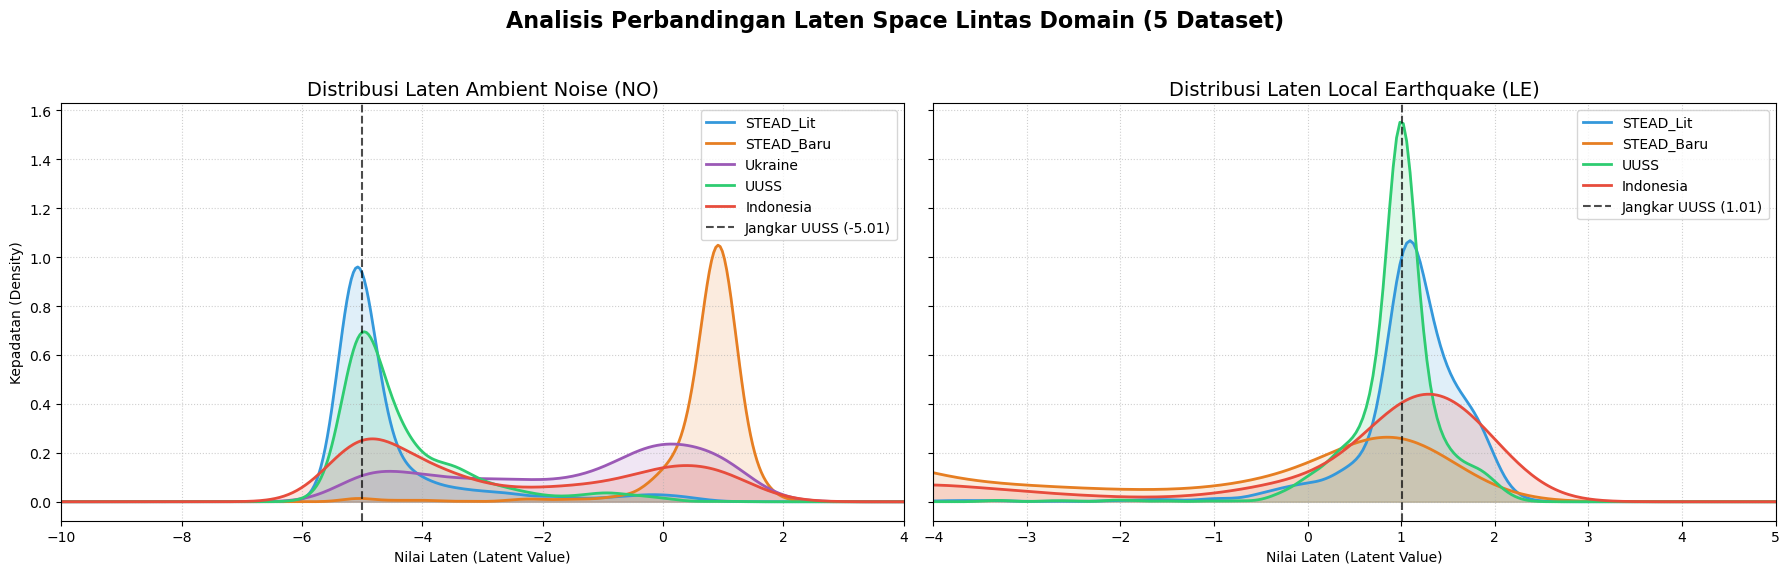

[INFO] Grafik telah berhasil di-render dan tersimpan di: /Volumes/Extreme SSD/mcu_quake_output_replikasi_demo/latent_space_comparison_extended.jpg


In [1]:
# ==========================================================================
# 8. EKSTRAKSI, KOMPARASI STATISTIK, & VISUALISASI LATENT SPACE LINTAS DOMAIN
# ==========================================================================    
import json
import numpy as np
import os
import csv
from tensorflow import keras
from Library import utils
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

def plot_kde(ax, data, label, color):
    """Fungsi bantuan untuk menggambar kurva distribusi KDE yang mulus"""
    if len(data) == 0:
        print(f"[DEBUG] Data untuk {label} kosong, melewati plot.")
        return
        
    data = np.array(data, dtype=float).flatten()
    
    try:
        kde = gaussian_kde(data)
        x_eval = np.linspace(-12, 6, 500) 
        ax.plot(x_eval, kde(x_eval), label=label, color=color, linewidth=2)
        ax.fill_between(x_eval, kde(x_eval), alpha=0.15, color=color)
    except Exception as e:
        print(f"[ERROR] Gagal merender kurva {label}: {e}")

def evaluate_and_visualize_latent_extended():
    print("="*65)
    print("[INFO] Memulai Ekstraksi & Visualisasi Latent Space (5 Domain)")
    print("="*65)
    
    np.random.seed(42) 
    
    BASE_REP = "/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/mcquake_ori_file/Code & Figure demo"
    MODEL_PATH = os.path.join(BASE_REP, "Pre-trained model/MCU-Quake 5-20")
    
    import tensorflow as tf
    tf.get_logger().setLevel('ERROR')
    
    try:
        embedding_model = keras.models.load_model(filepath=MODEL_PATH)
        print("[SUCCESS] Model MCU-Quake berhasil dimuat.")
    except Exception as e:
        print(f"[ERROR] Gagal memuat model: {e}")
        return

    data_paths = {
        "STEAD_Lit": "/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/mcquake_ori_file/Benchmark_ STEAD 3C_ test n15275 r100/STEAD data, test n15275 r100.json",
        "STEAD_Baru": "/Volumes/Extreme SSD/stream_stead/data_stead/STEAD_10000_Harmonized_Final.json",
        "Ukraine": "/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/mcquake_ori_file/Benchmark_ Ukraine 3C_ test n1335 r100 sdb8-956/Ukraine data, test n1335 r100 sdb8-956.json",
        "UUSS": "/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/mcquake_ori_file/Benchmark_ UUSS 3C_ test n2222 r100/UUSS 3C data, test n2222 r100.json",
        #"Indonesia": "/Volumes/Extreme SSD/output_json_indonesia/extracted_data_3comp.json", #data_sesi_1
        #"Indonesia": "/Volumes/Extreme SSD/unduhan_waveform_merged/extracted_data_3comp.json" #data_sesi_2
        'Indonesia': "/Volumes/Extreme SSD/json_juli_1c_3c/extracted_data_3c_sesi_clean.json"
    }
    
    num_points = 700 
    n_samples = 1000 
    
    latent_results = {"LE": {}, "NO": {}}
    colors = {
        "STEAD_Lit": "#3498db", 
        "STEAD_Baru": "#e67e22", 
        "Ukraine": "#9b59b6", 
        "UUSS": "#2ecc71", 
        "Indonesia": "#e74c3c"
    }

    for domain_name, path in data_paths.items():
        if not os.path.exists(path):
            print(f"[WARNING] Path tidak ditemukan: {domain_name}")
            continue
            
        print(f"\n[INFO] Ekstraksi {domain_name}...")
        with open(path, 'r') as f:
            data = json.load(f)
            
        le_temp = []
        no_temp = []
        
        for key, record in data.items():
            label = record.get("type", "").lower()
            if "Z" not in record or "Z_noise" not in record: continue
                
            try:
                Z_s = record["Z"][:num_points]
                Z_n = record["Z_noise"][-num_points:]
                
                emb_n = utils.latent_codes_1D(Z_n, embedding_model)
                no_temp.append(emb_n)
                
                if label in ["le", "se", "eq", "earthquake"]:
                    emb_s = utils.latent_codes_1D(Z_s, embedding_model)
                    le_temp.append(emb_s)
            except Exception:
                continue
        
        try:
            if len(le_temp) >= n_samples:
                idx_le = np.random.choice(len(le_temp), n_samples, replace=False)
                le_final = np.array(le_temp, dtype=float)[idx_le].flatten()
            else:
                le_final = np.array(le_temp, dtype=float).flatten()
                
            if len(no_temp) >= n_samples:
                idx_no = np.random.choice(len(no_temp), n_samples, replace=False)
                no_final = np.array(no_temp, dtype=float)[idx_no].flatten()
            else:
                no_final = np.array(no_temp, dtype=float).flatten()
                
        except Exception as e:
            print(f"[ERROR] Dimensi matriks tidak sesuai saat downsampling {domain_name}: {e}")
            le_final, no_final = [], []
            
        latent_results["LE"][domain_name] = le_final
        latent_results["NO"][domain_name] = no_final
        print(f" -> Disampel & Siap Plot: {len(le_final)} LE, {len(no_final)} NO")

    # ==========================================
    # GENERASI TABEL ANGKA & EKSPOR CSV
    # ==========================================
    print("\n" + "="*85)
    print(f"{'TABEL STATISTIK TOPOLOGI LATENT SPACE LINTAS DOMAIN':^85}")
    print("="*85)
    print(f"{'Domain Data':<15} | {'Kelas LE (Earthquake)':^31} | {'Kelas NO (Noise)':^31}")
    print(f"{'':<15} | {'N':^6} | {'Mean (μ)':^10} | {'Std (σ)':^10} | {'N':^6} | {'Mean (μ)':^10} | {'Std (σ)':^10}")
    print("-"*85)
    
    # Path untuk menyimpan CSV
    csv_save_path = "/Volumes/Extreme SSD/mcu_quake_output_replikasi_demo/latent_space_statistics.csv"
    
    # Membuka file CSV untuk proses penulisan
    with open(csv_save_path, mode='w', newline='') as csv_file:
        csv_writer = csv.writer(csv_file)
        # Menuliskan header kolom
        csv_writer.writerow(['Domain Data', 'N_LE', 'Mean_LE', 'Std_LE', 'N_NO', 'Mean_NO', 'Std_NO'])
        
        for domain_name in data_paths.keys():
            if domain_name not in latent_results["LE"]:
                continue
                
            le_arr = latent_results["LE"][domain_name]
            no_arr = latent_results["NO"][domain_name]
            
            n_le = len(le_arr)
            mu_le = np.mean(le_arr) if n_le > 0 else float('nan')
            sigma_le = np.std(le_arr) if n_le > 0 else float('nan')
            
            n_no = len(no_arr)
            mu_no = np.mean(no_arr) if n_no > 0 else float('nan')
            sigma_no = np.std(no_arr) if n_no > 0 else float('nan')
            
            # Print ke Terminal
            str_mu_le = f"{mu_le:>10.3f}" if not np.isnan(mu_le) else f"{'N/A':^10}"
            str_sig_le = f"{sigma_le:>10.3f}" if not np.isnan(sigma_le) else f"{'N/A':^10}"
            str_mu_no = f"{mu_no:>10.3f}" if not np.isnan(mu_no) else f"{'N/A':^10}"
            str_sig_no = f"{sigma_no:>10.3f}" if not np.isnan(sigma_no) else f"{'N/A':^10}"
            print(f"{domain_name:<15} | {n_le:^6} | {str_mu_le} | {str_sig_le} | {n_no:^6} | {str_mu_no} | {str_sig_no}")
            
            # Tulis ke file CSV
            csv_writer.writerow([domain_name, n_le, mu_le, sigma_le, n_no, mu_no, sigma_no])
            
    print("="*85)
    print(f"[INFO] Tabel statistik berhasil disimpan di: {csv_save_path}\n")

    # ==========================================
    # VISUALISASI KDE
    # ==========================================
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6), sharey=True)
    fig.suptitle('Analisis Perbandingan Laten Space Lintas Domain (5 Dataset)', fontsize=16, fontweight='bold')

    # PLOT 1: NOISE (NO)
    for domain in latent_results["NO"]:
        plot_kde(ax1, latent_results["NO"][domain], domain, colors[domain])
    ax1.axvline(x=-5.01, color='black', linestyle='--', alpha=0.7, label='Jangkar UUSS (-5.01)')
    ax1.set_title('Distribusi Laten Ambient Noise (NO)', fontsize=14)
    ax1.set_xlabel('Nilai Laten (Latent Value)')
    ax1.set_ylabel('Kepadatan (Density)')
    ax1.set_xlim(-10, 4)
    ax1.legend()
    ax1.grid(True, linestyle=':', alpha=0.6)

    # PLOT 2: EARTHQUAKE (LE)
    for domain in latent_results["LE"]:
        if len(latent_results["LE"][domain]) > 0: 
            plot_kde(ax2, latent_results["LE"][domain], domain, colors[domain])
    ax2.axvline(x=1.01, color='black', linestyle='--', alpha=0.7, label='Jangkar UUSS (1.01)')
    ax2.set_title('Distribusi Laten Local Earthquake (LE)', fontsize=14)
    ax2.set_xlabel('Nilai Laten (Latent Value)')
    ax2.set_xlim(-4, 5)
    ax2.legend()
    ax2.grid(True, linestyle=':', alpha=0.6)

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    
    save_path = "/Volumes/Extreme SSD/mcu_quake_output_replikasi_demo/latent_space_comparison_extended.jpg"
    plt.savefig(save_path, dpi=300)
    plt.show()
    print(f"[INFO] Grafik telah berhasil di-render dan tersimpan di: {save_path}")

if __name__ == "__main__":
    evaluate_and_visualize_latent_extended()

In [2]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
ANALISIS PERBANDINGAN LATEN SPACE 5 DOMAIN (STEAD_Lit, STEAD_Baru, Ukraine, UUSS, Indonesia)
Ekstraksi embedding dengan MCU-Quake, visualisasi KDE terpisah antara NO dan LE,
serta ekspor statistik ke CSV.
"""

import json
import os
import csv
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde
from tensorflow import keras
import warnings
warnings.filterwarnings('ignore')

# =============================================
# 1. KONFIGURASI
# =============================================

# Konfigurasi path
BASE_REP = "/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/mcquake_ori_file/Code & Figure demo"
MODEL_PATH = os.path.join(BASE_REP, "Pre-trained model/MCU-Quake 5-20")

DATA_PATHS = {
    "STEAD_Lit": "/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/mcquake_ori_file/Benchmark_ STEAD 3C_ test n15275 r100/STEAD data, test n15275 r100.json",
    "STEAD_Baru": "/Volumes/Extreme SSD/stream_stead/data_stead/STEAD_10000_Harmonized_Final.json",
    "Ukraine": "/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/mcquake_ori_file/Benchmark_ Ukraine 3C_ test n1335 r100 sdb8-956/Ukraine data, test n1335 r100 sdb8-956.json",
    "UUSS": "/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/mcquake_ori_file/Benchmark_ UUSS 3C_ test n2222 r100/UUSS 3C data, test n2222 r100.json",
    "Indonesia": "/Volumes/Extreme SSD/unduhan_waveform_merged/extracted_data_3comp.json"
}

OUTPUT_DIR = "/Volumes/Extreme SSD/mcu_quake_output_replikasi_demo/latent_space_analysis"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Parameter
NUM_POINTS = 700
N_SAMPLES = 1000  # downsampling untuk visualisasi
RANDOM_STATE = 42

# Warna untuk setiap domain
COLORS = {
    "STEAD_Lit": "#3498db",   # biru
    "STEAD_Baru": "#e67e22",  # orange
    "Ukraine": "#9b59b6",     # ungu
    "UUSS": "#2ecc71",        # hijau
    "Indonesia": "#e74c3c"    # merah
}

# Label untuk legenda
LABELS = {
    "STEAD_Lit": "STEAD (Literatur)",
    "STEAD_Baru": "STEAD (Baru)",
    "Ukraine": "Ukraine",
    "UUSS": "UUSS (Training)",
    "Indonesia": "Indonesia (Test)"
}

# Referensi dari paper
REFERENCE = {
    "NO": -5.01,
    "LE": 1.01,
    "QB": 1.96
}

# =============================================
# 2. FUNGSI UTILITY
# =============================================

def load_model():
    """Memuat model MCU-Quake."""
    try:
        model = keras.models.load_model(MODEL_PATH)
        print("[SUCCESS] Model MCU-Quake berhasil dimuat.")
        return model
    except Exception as e:
        print(f"[ERROR] Gagal memuat model: {e}")
        return None

def extract_embeddings(data, model, num_points=700, n_samples=1000):
    """
    Ekstrak embedding untuk kelas LE dan NO dari dataset.
    Return: (le_embeddings, no_embeddings)
    """
    le_temp = []
    no_temp = []
    
    for key, record in data.items():
        # Cek keberadaan komponen Z
        if "Z" not in record or "Z_noise" not in record:
            continue
        
        label = record.get("type", "").lower()
        
        try:
            # Ambil sinyal dan noise
            z_signal = record["Z"][:num_points]
            z_noise = record["Z_noise"][-num_points:]
            
            # Hitung embedding
            emb_noise = utils.latent_codes_1D(z_noise, model)
            no_temp.append(emb_noise)
            
            # Tentukan label
            if label in ["le", "se", "eq", "earthquake"]:
                emb_signal = utils.latent_codes_1D(z_signal, model)
                le_temp.append(emb_signal)
                
        except Exception as e:
            continue
    
    # Downsampling untuk visualisasi
    np.random.seed(RANDOM_STATE)
    
    if len(le_temp) > n_samples:
        idx = np.random.choice(len(le_temp), n_samples, replace=False)
        le_final = np.array(le_temp, dtype=float)[idx].flatten()
    else:
        le_final = np.array(le_temp, dtype=float).flatten() if le_temp else np.array([])
    
    if len(no_temp) > n_samples:
        idx = np.random.choice(len(no_temp), n_samples, replace=False)
        no_final = np.array(no_temp, dtype=float)[idx].flatten()
    else:
        no_final = np.array(no_temp, dtype=float).flatten() if no_temp else np.array([])
    
    return le_final, no_final

def compute_kde(data, x_range):
    """Hitung KDE untuk data."""
    if len(data) == 0:
        return None, None
    try:
        kde = gaussian_kde(data)
        return x_range, kde(x_range)
    except Exception as e:
        return None, None

# =============================================
# 3. FUNGSI VISUALISASI
# =============================================

def plot_kde_comparison(latent_results, output_dir):
    """
    Plot perbandingan KDE untuk NO dan LE dalam dua subplot terpisah.
    """
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6), sharey=True)
    fig.suptitle('Perbandingan Distribusi Laten Space MCU-Quake (5 Domain)', 
                 fontsize=16, fontweight='bold')
    
    # --- Plot 1: Noise (NO) ---
    for domain in latent_results["NO"]:
        data = latent_results["NO"][domain]
        if len(data) == 0:
            continue
        x_range = np.linspace(-12, 6, 500)
        try:
            kde = gaussian_kde(data)
            y = kde(x_range)
            ax1.plot(x_range, y, label=LABELS.get(domain, domain), 
                     color=COLORS.get(domain, 'gray'), linewidth=2)
            ax1.fill_between(x_range, y, alpha=0.15, color=COLORS.get(domain, 'gray'))
        except Exception as e:
            print(f"[WARNING] Gagal plot KDE untuk {domain} (NO): {e}")
    
    # Garis referensi noise dari paper
    ax1.axvline(x=REFERENCE["NO"], color='black', linestyle='--', 
                alpha=0.7, linewidth=1.5, label=f'Paper NO: {REFERENCE["NO"]}')
    ax1.set_title('Distribusi Laten: Noise (NO)', fontsize=14)
    ax1.set_xlabel('Nilai Laten (Embedding Value)')
    ax1.set_ylabel('Kepadatan (Density)')
    ax1.set_xlim(-10, 4)
    ax1.legend(loc='upper left')
    ax1.grid(True, linestyle=':', alpha=0.6)
    
    # --- Plot 2: Earthquake (LE) ---
    for domain in latent_results["LE"]:
        data = latent_results["LE"][domain]
        if len(data) == 0:
            continue
        x_range = np.linspace(-4, 5, 500)
        try:
            kde = gaussian_kde(data)
            y = kde(x_range)
            ax2.plot(x_range, y, label=LABELS.get(domain, domain), 
                     color=COLORS.get(domain, 'gray'), linewidth=2)
            ax2.fill_between(x_range, y, alpha=0.15, color=COLORS.get(domain, 'gray'))
        except Exception as e:
            print(f"[WARNING] Gagal plot KDE untuk {domain} (LE): {e}")
    
    # Garis referensi earthquake dari paper
    ax2.axvline(x=REFERENCE["LE"], color='black', linestyle='--', 
                alpha=0.7, linewidth=1.5, label=f'Paper LE: {REFERENCE["LE"]}')
    ax2.set_title('Distribusi Laten: Gempa (LE)', fontsize=14)
    ax2.set_xlabel('Nilai Laten (Embedding Value)')
    ax2.set_xlim(-4, 5)
    ax2.legend(loc='upper left')
    ax2.grid(True, linestyle=':', alpha=0.6)
    
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    save_path = os.path.join(output_dir, 'latent_space_comparison_5domains.png')
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.close()
    print(f"[INFO] Grafik tersimpan di: {save_path}")
    
    return fig

def plot_separate_kde(latent_results, output_dir):
    """
    Plot KDE terpisah antara NO dan LE dalam satu figure dengan grid yang lebih detail.
    """
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle('Perbandingan Laten Space MCU-Quake (5 Domain)', 
                 fontsize=16, fontweight='bold')
    
    # --- Plot 1: Semua Domain NO ---
    ax = axes[0, 0]
    for domain in latent_results["NO"]:
        data = latent_results["NO"][domain]
        if len(data) == 0:
            continue
        x_range = np.linspace(-12, 6, 500)
        try:
            kde = gaussian_kde(data)
            ax.plot(x_range, kde(x_range), label=LABELS.get(domain, domain), 
                    color=COLORS.get(domain, 'gray'), linewidth=2)
        except:
            pass
    ax.axvline(x=REFERENCE["NO"], color='black', linestyle='--', 
               alpha=0.7, label=f'Paper NO: {REFERENCE["NO"]}')
    ax.set_title('Distribusi Laten: NO (Semua Domain)', fontsize=13)
    ax.set_xlabel('Nilai Laten')
    ax.set_ylabel('Kepadatan')
    ax.set_xlim(-10, 4)
    ax.legend(loc='upper left')
    ax.grid(True, linestyle=':', alpha=0.6)
    
    # --- Plot 2: Semua Domain LE ---
    ax = axes[0, 1]
    for domain in latent_results["LE"]:
        data = latent_results["LE"][domain]
        if len(data) == 0:
            continue
        x_range = np.linspace(-4, 5, 500)
        try:
            kde = gaussian_kde(data)
            ax.plot(x_range, kde(x_range), label=LABELS.get(domain, domain), 
                    color=COLORS.get(domain, 'gray'), linewidth=2)
        except:
            pass
    ax.axvline(x=REFERENCE["LE"], color='black', linestyle='--', 
               alpha=0.7, label=f'Paper LE: {REFERENCE["LE"]}')
    ax.set_title('Distribusi Laten: LE (Semua Domain)', fontsize=13)
    ax.set_xlabel('Nilai Laten')
    ax.set_ylabel('Kepadatan')
    ax.set_xlim(-4, 5)
    ax.legend(loc='upper left')
    ax.grid(True, linestyle=':', alpha=0.6)
    
    # --- Plot 3: Perbandingan NO vs LE per Domain (Indonesia sebagai fokus) ---
    ax = axes[1, 0]
    # Plot NO dan LE untuk Indonesia
    domain = "Indonesia"
    if domain in latent_results["NO"] and len(latent_results["NO"][domain]) > 0:
        data_no = latent_results["NO"][domain]
        x_range = np.linspace(-10, 6, 500)
        try:
            kde_no = gaussian_kde(data_no)
            ax.plot(x_range, kde_no(x_range), label=f'{LABELS.get(domain, domain)} NO', 
                    color='red', linestyle='--', linewidth=2)
        except:
            pass
    if domain in latent_results["LE"] and len(latent_results["LE"][domain]) > 0:
        data_le = latent_results["LE"][domain]
        x_range = np.linspace(-4, 5, 500)
        try:
            kde_le = gaussian_kde(data_le)
            ax.plot(x_range, kde_le(x_range), label=f'{LABELS.get(domain, domain)} LE', 
                    color='blue', linestyle='-', linewidth=2)
        except:
            pass
    ax.axvline(x=REFERENCE["NO"], color='red', linestyle=':', alpha=0.5, label=f'Paper NO: {REFERENCE["NO"]}')
    ax.axvline(x=REFERENCE["LE"], color='blue', linestyle=':', alpha=0.5, label=f'Paper LE: {REFERENCE["LE"]}')
    ax.set_title('Indonesia: Overlay NO vs LE', fontsize=13)
    ax.set_xlabel('Nilai Laten')
    ax.set_ylabel('Kepadatan')
    ax.set_xlim(-8, 5)
    ax.legend(loc='upper left')
    ax.grid(True, linestyle=':', alpha=0.6)
    
    # --- Plot 4: Perbandingan Semua Domain (NO vs LE) untuk Indonesia vs UUSS ---
    ax = axes[1, 1]
    domains_compare = ["UUSS", "Indonesia"]
    for d in domains_compare:
        if d in latent_results["NO"] and len(latent_results["NO"][d]) > 0:
            data_no = latent_results["NO"][d]
            x_range = np.linspace(-10, 6, 500)
            try:
                kde_no = gaussian_kde(data_no)
                ax.plot(x_range, kde_no(x_range), 
                        label=f'{LABELS.get(d, d)} NO', 
                        color=COLORS.get(d, 'gray'), linestyle='--', linewidth=2)
            except:
                pass
        if d in latent_results["LE"] and len(latent_results["LE"][d]) > 0:
            data_le = latent_results["LE"][d]
            x_range = np.linspace(-4, 5, 500)
            try:
                kde_le = gaussian_kde(data_le)
                ax.plot(x_range, kde_le(x_range), 
                        label=f'{LABELS.get(d, d)} LE', 
                        color=COLORS.get(d, 'gray'), linestyle='-', linewidth=2)
            except:
                pass
    ax.axvline(x=REFERENCE["NO"], color='black', linestyle=':', alpha=0.4)
    ax.axvline(x=REFERENCE["LE"], color='black', linestyle=':', alpha=0.4)
    ax.set_title('UUSS vs Indonesia: NO dan LE', fontsize=13)
    ax.set_xlabel('Nilai Laten')
    ax.set_ylabel('Kepadatan')
    ax.set_xlim(-8, 5)
    ax.legend(loc='upper left')
    ax.grid(True, linestyle=':', alpha=0.6)
    
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    save_path = os.path.join(output_dir, 'latent_space_separate_plots.png')
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.close()
    print(f"[INFO] Grafik terpisah tersimpan di: {save_path}")
    
    return fig

def export_statistics(latent_results, output_dir):
    """
    Ekspor statistik deskriptif ke CSV.
    """
    csv_path = os.path.join(output_dir, 'latent_statistics.csv')
    with open(csv_path, 'w', newline='') as f:
        writer = csv.writer(f)
        writer.writerow(['Domain', 'Class', 'N', 'Mean', 'Std', 'Min', 'Max', 'Median'])
        
        for domain in latent_results["LE"]:
            le_data = latent_results["LE"][domain]
            no_data = latent_results["NO"][domain]
            
            if len(le_data) > 0:
                writer.writerow([
                    domain, 'LE', 
                    len(le_data), 
                    f"{np.mean(le_data):.4f}",
                    f"{np.std(le_data):.4f}",
                    f"{np.min(le_data):.4f}",
                    f"{np.max(le_data):.4f}",
                    f"{np.median(le_data):.4f}"
                ])
            if len(no_data) > 0:
                writer.writerow([
                    domain, 'NO', 
                    len(no_data), 
                    f"{np.mean(no_data):.4f}",
                    f"{np.std(no_data):.4f}",
                    f"{np.min(no_data):.4f}",
                    f"{np.max(no_data):.4f}",
                    f"{np.median(no_data):.4f}"
                ])
    
    print(f"[INFO] Statistik tersimpan di: {csv_path}")
    
    # Cetak ringkasan ke terminal
    print("\n" + "="*85)
    print(f"{'TABEL STATISTIK LATEN SPACE LINTAS DOMAIN':^85}")
    print("="*85)
    print(f"{'Domain':<15} | {'Kelas':^6} | {'N':^8} | {'Mean (μ)':^12} | {'Std (σ)':^12}")
    print("-"*85)
    for domain in latent_results["LE"]:
        le_data = latent_results["LE"][domain]
        no_data = latent_results["NO"][domain]
        if len(le_data) > 0:
            print(f"{domain:<15} | {'LE':^6} | {len(le_data):^8} | {np.mean(le_data):>12.4f} | {np.std(le_data):>12.4f}")
        if len(no_data) > 0:
            print(f"{domain:<15} | {'NO':^6} | {len(no_data):^8} | {np.mean(no_data):>12.4f} | {np.std(no_data):>12.4f}")
    print("="*85)

# =============================================
# 4. FUNGSI UTAMA
# =============================================

def main():
    print("="*65)
    print("[INFO] ANALISIS LATEN SPACE 5 DOMAIN (MCU-QUAKE)")
    print("="*65)
    
    # Load model
    model = load_model()
    if model is None:
        return
    
    # Import utils
    import sys
    sys.path.insert(0, "/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying")
    from Library import utils
    
    latent_results = {"LE": {}, "NO": {}}
    
    # Ekstraksi embedding per domain
    for domain_name, path in DATA_PATHS.items():
        if not os.path.exists(path):
            print(f"[WARNING] Path tidak ditemukan: {domain_name}")
            continue
            
        print(f"\n[INFO] Ekstraksi {domain_name}...")
        with open(path, 'r') as f:
            data = json.load(f)
        
        le_emb, no_emb = extract_embeddings(data, model, NUM_POINTS, N_SAMPLES)
        latent_results["LE"][domain_name] = le_emb
        latent_results["NO"][domain_name] = no_emb
        
        print(f" -> LE: {len(le_emb)} sample, NO: {len(no_emb)} sample")
    
    # Visualisasi
    print("\n[INFO] Membuat visualisasi...")
    plot_kde_comparison(latent_results, OUTPUT_DIR)
    plot_separate_kde(latent_results, OUTPUT_DIR)
    
    # Ekspor statistik
    export_statistics(latent_results, OUTPUT_DIR)
    
    print(f"\n[SUCCESS] Semua output tersimpan di: {OUTPUT_DIR}")
    print("="*65)

if __name__ == "__main__":
    main()

[INFO] ANALISIS LATEN SPACE 5 DOMAIN (MCU-QUAKE)
[SUCCESS] Model MCU-Quake berhasil dimuat.

[INFO] Ekstraksi STEAD_Lit...
 -> LE: 1000 sample, NO: 1000 sample

[INFO] Ekstraksi STEAD_Baru...
 -> LE: 1000 sample, NO: 1000 sample

[INFO] Ekstraksi Ukraine...
 -> LE: 0 sample, NO: 1000 sample

[INFO] Ekstraksi UUSS...
 -> LE: 1000 sample, NO: 1000 sample

[INFO] Ekstraksi Indonesia...
 -> LE: 1000 sample, NO: 1000 sample

[INFO] Membuat visualisasi...
[INFO] Grafik tersimpan di: /Volumes/Extreme SSD/mcu_quake_output_replikasi_demo/latent_space_analysis/latent_space_comparison_5domains.png
[INFO] Grafik terpisah tersimpan di: /Volumes/Extreme SSD/mcu_quake_output_replikasi_demo/latent_space_analysis/latent_space_separate_plots.png
[INFO] Statistik tersimpan di: /Volumes/Extreme SSD/mcu_quake_output_replikasi_demo/latent_space_analysis/latent_statistics.csv

                      TABEL STATISTIK LATEN SPACE LINTAS DOMAIN                      
Domain          | Kelas  |    N     |   Mean (μ